# EdgeTRM (Official TRM path, notebook-friendly)

This notebook uses the **official TinyRecursiveModels TRM + ACT loss** through a thin adapter, instead of re-implementing recursion in-notebook.

Goal: provide a small, runnable baseline where loss decreases reliably, then you can swap in Sudoku/ARC data.

In [1]:
import torch
# At the top of your notebook, before building the model:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True



In [2]:
!git clone https://github.com/Seqaeon/EdgeTRM.git

Cloning into 'EdgeTRM'...
remote: Enumerating objects: 122, done.
remote: Counting objects: 100% (122/122), done.
remote: Compressing objects: 100% (88/88), done.
remote: Total 122 (delta 55), reused 87 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (122/122), 1.95 MiB | 8.08 MiB/s, done.
Resolving deltas: 100% (55/55), done.


In [3]:
!git pull origin main

fatal: not a git repository (or any of the parent directories): .git


In [4]:
import os
# os.chdir("/root/EdgeTRM/TinyRecursiveModels")
os.chdir("/root/EdgeTRM")
print(os.getcwd())


/root/EdgeTRM


In [5]:
from pathlib import Path
import sys

repo_root = Path.cwd()
trm_root = repo_root / "TinyRecursiveModels"
if str(trm_root) not in sys.path:
    sys.path.insert(0, str(trm_root))

print("repo_root:", repo_root)
print("trm_root:", trm_root)

repo_root: /root/EdgeTRM
trm_root: /root/EdgeTRM/TinyRecursiveModels


In [6]:
import torch
print("PyTorch CUDA available:", torch.cuda.is_available())
print("CUDA version (from PyTorch):", torch.version.cuda)
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


PyTorch CUDA available: True
CUDA version (from PyTorch): 12.9
GPU name: NVIDIA H100 80GB HBM3


In [7]:
# %pip install torch==2.7.0+cu126


In [8]:
# import os
# import subprocess
# req_file = os.path.join(trm_root, "requirements.txt")
# special_req_file = os.path.join(trm_root, "specific_requirements.txt")
# %uv pip install -r {req_file}
# %uv pip install -r {special_req_file}
# # %pip install torch==2.7.0+cu126
%uv pip install {trm_root}


Using Python 3.12.6 environment at: /usr/local
Resolved 63 packages in 1.82s
Building antlr4-python3-runtime==4.9.3
Building antlr4-python3-runtime==4.9.3
Building tiny-recursive-models @ file:///root/EdgeTRM/TinyRecursiveModels
Building antlr4-python3-runtime==4.9.3
Building tiny-recursive-models @ file:///root/EdgeTRM/TinyRecursiveModels
Building adam-atan2==0.0.3
Building antlr4-python3-runtime==4.9.3
Building tiny-recursive-models @ file:///root/EdgeTRM/TinyRecursiveModels
Building adam-atan2==0.0.3
⠙ Preparing packages... (0/34)
Building antlr4-python3-runtime==4.9.3
Building tiny-recursive-models @ file:///root/EdgeTRM/TinyRecursiveModels
Building adam-atan2==0.0.3
⠙ Preparing packages... (0/34)
Building antlr4-python3-runtime==4.9.3
Building tiny-recursive-models @ file:///root/EdgeTRM/TinyRecursiveModels
Building adam-atan2==0.0.3
⠙ Preparing packages... (0/34)
argdantic  ------------------------------     0 B/26.32 KiB
Building antlr4-python3-runtime==4.9.3
Building tiny-recur

In [9]:
import torch
from edge_trm_wrapper import EdgeTRMAdapter, EdgeTRMBatch

torch.manual_seed(7)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [10]:
import numpy as np
BATCH = 512
# ── Global experiment flags ─────────────────────────────────────────────────
SMOKE_TEST       = False          # True → quick run for CI / sanity; False → full eval
DEVICE           = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED             = 42
EPOCHS = 200 if SMOKE_TEST else 5000

CHECKPOINT_EVERY = 100   # e.g. save every 100 epochs
CHECKPOINT_DIR = Path('checkpoints')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)

## 1) Tiny config (fast sanity training)

This is intentionally tiny and uses `halt_max_steps=1` so each iteration is straightforward for debugging.

In [11]:
cfg = {
    "batch_size": BATCH,
    "seq_len": 12,
    "puzzle_emb_ndim": 0,
    "num_puzzle_identifiers": 1,
    "vocab_size": 16,
    "H_cycles": 1,
    "L_cycles": 1,
    "H_layers": 0,
    "L_layers": 1,
    "hidden_size": 64,
    "expansion": 2.0,
    "num_heads": 4,
    "pos_encodings": "rope",
    "halt_max_steps": 1,
    "halt_exploration_prob": 0.0,
    "forward_dtype": "float32",
    "mlp_t": False,
    "puzzle_emb_len": 0,
    "no_ACT_continue": True,
}

model = EdgeTRMAdapter(cfg, loss_type="stablemax_cross_entropy").to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
print("params:", sum(p.numel() for p in model.parameters()))

params: 67714


## 2) Synthetic task

Identity token reconstruction (`labels = inputs`).

If the training path is wired correctly, the loss should trend down quickly.

In [12]:
def make_batch(batch_size=32, seq_len=12, vocab_size=16, device=device):
    x = torch.randint(0, vocab_size, (batch_size, seq_len), device=device)
    y = x.clone()
    puzzle_ids = torch.zeros((batch_size,), dtype=torch.int32, device=device)
    return EdgeTRMBatch(inputs=x, labels=y, puzzle_identifiers=puzzle_ids)

In [13]:
model.train()
losses = []
lm_losses = []
accs = []

# fixed batch so you can verify optimization wiring by overfitting
batch = make_batch(cfg["batch_size"], cfg["seq_len"], cfg["vocab_size"])
carry = model.initial_carry(batch)
# Move carry tensors to selected device
carry.inner_carry.z_H = carry.inner_carry.z_H.to(device)
carry.inner_carry.z_L = carry.inner_carry.z_L.to(device)
carry.steps = carry.steps.to(device)
carry.halted = carry.halted.to(device)
carry.current_data = {k: v.to(device) for k, v in carry.current_data.items()}

for step in range(300):
    carry, loss, metrics, _, done = model.train_step(batch=batch, carry=carry)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    losses.append(float(loss.detach().cpu()))
    lm_losses.append(float((metrics["lm_loss"] / metrics["count"]).detach().cpu()))
    accs.append(float((metrics["accuracy"] / metrics["count"]).detach().cpu()))

    if step % 50 == 0:
        print(
            f"step={step:03d} total={losses[-1]:.4f} lm={lm_losses[-1]:.4f} tok_acc={accs[-1]:.4f}"
        )

print("start_lm_loss:", lm_losses[0], "end_lm_loss:", lm_losses[-1])
print("start_acc:", accs[0], "end_acc:", accs[-1])

step=000 total=1536.0483 lm=2.9967 tok_acc=0.0104
step=050 total=1770.4316 lm=1.0783 tok_acc=1.0000
step=100 total=1410.9700 lm=0.8510 tok_acc=1.0000
step=150 total=1111.2672 lm=0.8087 tok_acc=1.0000
step=200 total=801.8272 lm=0.7565 tok_acc=1.0000
step=250 total=561.4991 lm=0.6757 tok_acc=1.0000
start_lm_loss: 2.996736603967023 end_lm_loss: 0.5930594131680937
start_acc: 0.010416666977107525 end_acc: 1.0


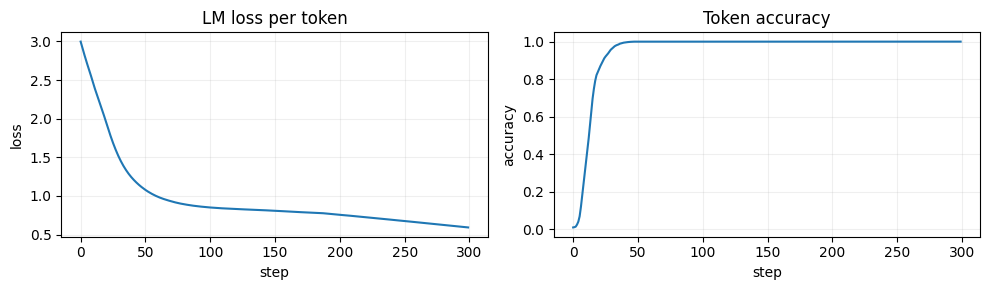

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(lm_losses)
ax[0].set_title("LM loss per token")
ax[0].set_xlabel("step")
ax[0].set_ylabel("loss")
ax[0].grid(alpha=0.2)

ax[1].plot(accs)
ax[1].set_title("Token accuracy")
ax[1].set_xlabel("step")
ax[1].set_ylabel("accuracy")
ax[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [15]:
2**19

524288

In [16]:

import subprocess
from pathlib import Path
import numpy as np
from torch.utils.data import TensorDataset, DataLoader



import csv
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from huggingface_hub import hf_hub_download

# Paper-style intent for this notebook:
# - train/val from easier Sudoku sources
# - test from Sudoku-Extreme test split
source_repo = 'sapientinc/sudoku-extreme'
train_csv = hf_hub_download(source_repo, 'train.csv', repo_type='dataset')
test_csv = hf_hub_download(source_repo, 'test.csv', repo_type='dataset')

EASY_SOURCES = {'puzzles0_kaggle', 'puzzles1_unbiased', 'puzzles2_17_clue'}
TRAIN_SUBSAMPLE = 1048576+1024
TEST_SUBSAMPLE = 400000

print('train_csv:', train_csv)
print('test_csv:', test_csv)
     

train.csv:   0%|          | 0.00/719M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/79.4M [00:00<?, ?B/s]

train_csv: /root/.cache/huggingface/hub/datasets--sapientinc--sudoku-extreme/snapshots/58942f96baeb572ca3127e2a9e9c70f330783d6b/train.csv
test_csv: /root/.cache/huggingface/hub/datasets--sapientinc--sudoku-extreme/snapshots/58942f96baeb572ca3127e2a9e9c70f330783d6b/test.csv


In [24]:
# import pandas as pd

# df = pd.read_csv(train_csv)
# df.sample(20)

,source,question,answer,rating
2047968,puzzles4_forum_hardest_1905,.5....7....3.8..9...926...4..8.1..6.........5....,8529437164631875927192653842785149633967281451...,42
3355892,puzzles4_forum_hardest_1905,...........86.4...57..8..6.85..6..3..9......2....,4615237899286741535731892648542679311963485722...,53
818412,puzzles4_forum_hardest_1905,9...7..4...6...5.7...3....9.8.....1.5...4.7......,9185762433469215872573841696827593145918437264...,26
2800131,puzzles1_unbiased,6.3...7............4.7..28....62..3.8.1.5....4...,6834127592753981461497652835976248318219534674...,3
990733,puzzles4_forum_hardest_1905,...9.1..5.5..7.6..1.....7.......2.6.5...9...7....,4789612353524786911965237488197325645248963177...,23
3396979,puzzles4_forum_hardest_1905,..4......1...7.2...2.8...5.7....4.....2.9.3......,5941328671869752343278469517153846296425973189...,43
1041788,puzzles4_forum_hardest_1905,2...5...7..7..36...8.7...1...6.3.7..9.......3....,2631594871574836924897263158165327499426178533...,37
1441048,puzzles1_unbiased,7.9.1......32.8.5....3..6.9.4.....97.............,7896154324632987515123746891468523973984672152...,0
2836413,01_file1,.5...8...2...4...........71.92..5..4..462.8..6...,7569184322317465899482536711923857645746218936...,33
3814005,puzzles4_forum_hardest_1905,..58.......2...1...3..2...5.....48..3...9...6....,9158436277426591388367219456215748933742985165...,48


In [22]:
# # Make sure the destination exists
# !mkdir -p /root/EdgeTRM/data/
# # Remove the broken symlinks
# !rm /root/EdgeTRM/data/train.csv /root/EdgeTRM/data/test.csv
# # Copy the actual files from the cache "blobs" directory
# !cp /root/.cache/huggingface/hub/datasets--sapientinc--sudoku-extreme/blobs/64b46674db0148e0d73a16346dadeb2b1c00824d3fca3f85b2ae7037f6b4b38e /root/EdgeTRM/data/train.csv
# !cp /root/.cache/huggingface/hub/datasets--sapientinc--sudoku-extreme/blobs/a2fd52aea23d331d5b4ee723c856236e838a9fb9a70e66f4e0e0cf26c338c6a8 /root/EdgeTRM/data/test.csv
# !ls -lh /root/EdgeTRM/data
# df = pd.read_csv("/root/EdgeTRM/data/test.csv")
# df.sample(20)


In [34]:

def _encode_grid(s: str) -> np.ndarray:
    # convert '.' blanks to 0, digits to ints, then +1 for PAD-aware vocab (0 reserved for PAD)
    arr = np.frombuffer(s.replace('.', '0').encode(), dtype=np.uint8) - ord('0')
    return (arr + 1).astype(np.int32)


def load_split_from_csv(path: str, use_sources=None, limit=None, seed: int = 7):
    rows = []
    with open(path, newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            if (use_sources is None) or (row['source'] in use_sources):
                rows.append((row['question'], row['answer']))

    rng = np.random.default_rng(seed)
    if limit is not None and limit < len(rows):
        idx = rng.choice(len(rows), size=limit, replace=False)
        rows = [rows[i] for i in idx]

    X = np.stack([_encode_grid(q) for q, _ in rows])
    Y = np.stack([_encode_grid(a) for _, a in rows])
    return X, Y

# Train/val: easy-only subset (proxy for paper training distribution)
X_easy, Y_easy = load_split_from_csv(train_csv, use_sources=EASY_SOURCES, limit=TRAIN_SUBSAMPLE, seed=7)

# Test: Sudoku-Extreme test split only
X_test, Y_test = load_split_from_csv(test_csv, use_sources=None, limit=TEST_SUBSAMPLE, seed=11)

n_train = int(0.85 * len(X_easy))
X_train, Y_train = X_easy[:n_train], Y_easy[:n_train]
X_val, Y_val = X_easy[n_train:], Y_easy[n_train:]

def make_loader(X_np, Y_np, batch_size=64, shuffle=True):
    ds = TensorDataset(torch.from_numpy(X_np), torch.from_numpy(Y_np))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=True)

train_loader = make_loader(X_train, Y_train, batch_size=BATCH, shuffle=True)
val_loader = make_loader(X_val, Y_val, batch_size=BATCH, shuffle=False)
test_loader = make_loader(X_test, Y_test, batch_size=BATCH, shuffle=False)

print('train/val/test shapes:', X_train.shape, X_val.shape, X_test.shape)

train/val/test shapes: (879410, 81) (155190, 81) (400000, 81)


In [35]:

def edge_batch_from_xy(x: torch.Tensor, y: torch.Tensor, device: torch.device, vocab_size: int = 11):
    x = x.to(device=device, dtype=torch.int32)
    y = y.to(device=device, dtype=torch.int32)

    # Safety guards: avoid CUDA gather/embedding OOB from unexpected tokens
    x = torch.clamp(x, min=0, max=vocab_size - 1)
    y = torch.where((y >= 0) & (y < vocab_size), y, torch.full_like(y, -100))
    y = torch.where(y == 0, torch.full_like(y, -100), y)  # PAD -> ignore label

    puzzle_ids = torch.zeros((x.shape[0],), dtype=torch.int32, device=device)
    return EdgeTRMBatch(inputs=x, labels=y, puzzle_identifiers=puzzle_ids)


def make_sudoku_cfg(batch_size: int = BATCH):
    return {
        "batch_size": batch_size,
        "seq_len": 81,
        "puzzle_emb_ndim": 0,
        "num_puzzle_identifiers": 1,
        "vocab_size": 10,   # digits 0..9
        "H_cycles": 3,
        "L_cycles": 6,
        "H_layers": 0,
        "L_layers": 2,
        "hidden_size": 256,
        "expansion": 4.0,
        "num_heads": 8,
        "pos_encodings": "rope",
        "halt_max_steps": 8,
        "halt_exploration_prob": 0.1,
        "forward_dtype": "float32",
        "mlp_t": False,
        "puzzle_emb_len": 0,
        "no_ACT_continue": True,
    }

In [36]:
sudoku_cfg = make_sudoku_cfg(batch_size=BATCH)
sudoku_model = EdgeTRMAdapter(sudoku_cfg, loss_type="stablemax_cross_entropy").to(device)
sudoku_opt = torch.optim.AdamW(sudoku_model.parameters(), lr=1e-4, weight_decay=1.0, betas=(0.9, 0.95))

# Initialize carry once and keep recurrent updates across batches
init_x, init_y = next(iter(train_loader))
init_batch = edge_batch_from_xy(init_x, init_y, device)
carry = sudoku_model.initial_carry(init_batch)
carry.inner_carry.z_H = carry.inner_carry.z_H.to(device)
carry.inner_carry.z_L = carry.inner_carry.z_L.to(device)
carry.steps = carry.steps.to(device)
carry.halted = carry.halted.to(device)
carry.current_data = {k: v.to(device) for k, v in carry.current_data.items()}

In [37]:
def run_epoch(model, loader, optimizer=None, carry=None):
    train_mode = optimizer is not None
    model.train(train_mode)

    lm_sum = acc_sum = count_sum = 0.0

    for x, y in loader:
        batch = edge_batch_from_xy(x, y, device)

        if carry is None:
            carry = model.initial_carry(batch)
            carry.inner_carry.z_H = carry.inner_carry.z_H.to(device)
            carry.inner_carry.z_L = carry.inner_carry.z_L.to(device)
            carry.steps = carry.steps.to(device)
            carry.halted = carry.halted.to(device)
            carry.current_data = {k: v.to(device) for k, v in carry.current_data.items()}

        with torch.set_grad_enabled(train_mode):
            carry, loss, metrics, _, _ = model.train_step(batch=batch, carry=carry)
            if train_mode:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        lm_sum += float(metrics["lm_loss"].detach().cpu())
        acc_sum += float(metrics["accuracy"].detach().cpu())
        count_sum += float(metrics["count"].detach().cpu())

    return {"lm": lm_sum / max(count_sum, 1.0), "tok_acc": acc_sum / max(count_sum, 1.0)}, carry

In [ ]:

# Quick token-range sanity check before training
xb, yb = next(iter(train_loader))
print('x range:', xb.min().item(), xb.max().item(), 'y range:', yb.min().item(), yb.max().item())



for epoch in range(EPOCHS):
    tr, carry = run_epoch(sudoku_model, train_loader, optimizer=sudoku_opt, carry=carry)
    va, carry = run_epoch(sudoku_model, val_loader, optimizer=None, carry=carry)
    print(f"epoch={epoch:02d} train_lm={tr['lm']:.4f} train_tok_acc={tr['tok_acc']:.4f} val_lm={va['lm']:.4f} val_tok_acc={va['tok_acc']:.4f}")

    if ((epoch + 1) % CHECKPOINT_EVERY == 0) or ((epoch + 1) == EPOCHS):
        ckpt_path = CHECKPOINT_DIR / f'sudoku_wrapper_epoch_{epoch+1:04d}.pt'
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': sudoku_model.state_dict(),
            'optimizer_state_dict': sudoku_opt.state_dict(),
            'train_metrics': tr,
            'val_metrics': va,
            'config': sudoku_cfg,
        }, ckpt_path)
        print(f'checkpoint saved: {ckpt_path}')

x range: 1 10 y range: 2 10
epoch=00 train_lm=10.1746 train_tok_acc=0.4899 val_lm=8.9412 val_tok_acc=0.5326
